In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [21]:
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=4, random_state=42)

In [22]:
df0 = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [23]:
df0

,Feature_1,Feature_2
0,-2.282534,-9.692815
1,-6.147668,1.755990
2,13.399091,-1.260023
3,-4.077630,3.160226
4,9.444735,0.340868
...,...,...
495,-1.282205,-3.181575
496,-2.817604,10.378894
497,3.296740,8.649256
498,-8.970519,-2.684073


In [24]:
scaler = StandardScaler()
X_Scaled = scaler.fit_transform(X)

In [25]:
inertia = []
K_range = range(1, 11)

In [26]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_Scaled)
    inertia.append(kmeans.inertia_)

In [27]:
inertia

[999.9999999999991,
 528.8064432605648,
 294.4377068678187,
 250.45524696534443,
 216.881106569826,
 185.27440675195902,
 156.70879996290444,
 135.62603453115247,
 129.1039634823981,
 119.94101297104993]

In [28]:
df = pd.DataFrame(inertia)

<Axes: >

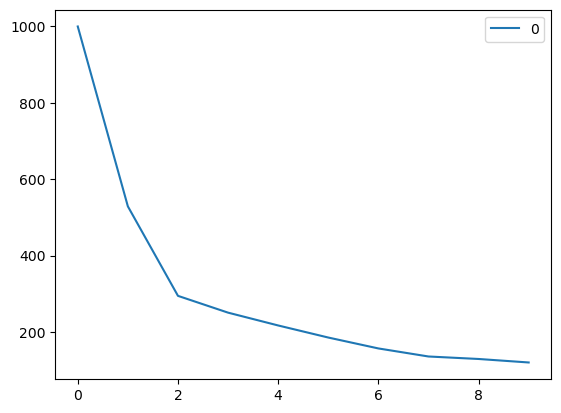

In [29]:
sns.lineplot(data=df)

In [30]:
kmeans_final = KMeans(n_clusters=8, random_state=42)

In [31]:
kmeans_final

,n_clusters,8
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [32]:
cluster_labels = kmeans_final.fit_predict(X_Scaled)

In [34]:
df0['cluster'] = cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

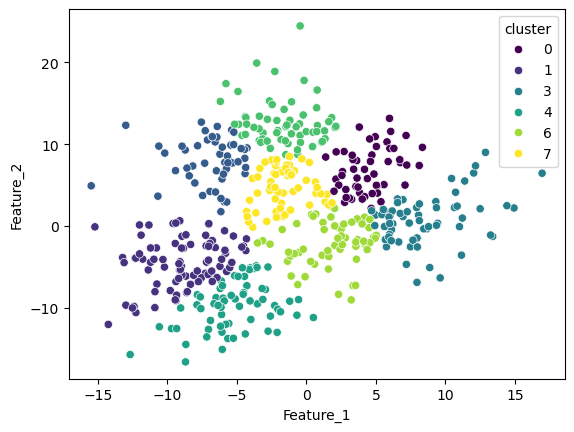

In [37]:
sns.scatterplot(x=df0['Feature_1'],
                y=df0['Feature_2'],
                hue=df0['cluster'],
                palette='viridis')